In [34]:
#small dataset
# https://www.kaggle.com/datasets/heavensky/image-dataset-for-unsupervised-clustering
#Lab 08
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.linear_model import LinearRegression

from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification

In [35]:
import kagglehub

# Download latest version
#path = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")

#print("Path to dataset files:", path)

In [36]:
def LoadImage(path, size=(64, 64)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img = img.astype(np.float32) / 255.0
    return img



In [37]:
import os
# the dataset has 1000 images, it may be a bit too big, it was mostly for testing the CNN
# Path fixing
dataset_path = "/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1"
folders = ['cats_set', 'dogs_set']

cats_paths = [os.path.join(dataset_path, folders[0], f) for f in os.listdir(os.path.join(dataset_path, folders[0]))]
dogs_paths = [os.path.join(dataset_path, folders[1], f) for f in os.listdir(os.path.join(dataset_path, folders[1]))]

print("Cats:", cats_paths[:3])
print("Dogs:", dogs_paths[:3])

Cats: ['/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/cats_set/cat.4339.jpg', '/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/cats_set/cat.4103.jpg', '/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/cats_set/cat.4497.jpg']
Dogs: ['/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/dogs_set/dog.4276.jpg', '/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/dogs_set/dog.4287.jpg', '/home/snorre/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/dogs_set/dog.4429.jpg']


In [38]:
# Main Program
X = []
Y = []
#Place images in array and labels
for path in cats_paths:
    img = LoadImage(path)
    X.append(img)
    Y.append(0)
for path in dogs_paths:
    img = LoadImage(path)
    X.append(img)
    Y.append(1)

X = np.array(X, dtype=np.float32)
y = np.array(Y)
print(f"Loaded {len(X)} images, shape: {X.shape}, labels: {np.unique(y)}")

Loaded 1000 images, shape: (1000, 64, 64, 3), labels: [0 1]


In [39]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

#
y_cat = to_categorical(y, num_classes=2)
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=10)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (800, 64, 64, 3), Test shape: (200, 64, 64, 3)


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

#define a simple CNN
model = Sequential([
    Input(shape=(64,64,3)),
    Conv2D(16, (3,3), activation='relu'),   # First conv layer
    MaxPooling2D((2,2)),                    # Pooling layer
    Flatten(),                              # Flatten features
    Dense(64, activation='relu'),           # Dense layer to combine features
    Dense(2, activation='softmax')          # Output layer for cat vs dog
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/home/snorre/Desktop/computervision/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15376)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       984,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 984,706 (3.76 MB)

 Trainable params: 984,706 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=8
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5275 - loss: 0.7285 - val_accuracy: 0.6250 - val_loss: 0.6762
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5962 - loss: 0.6744 - val_accuracy: 0.6050 - val_loss: 0.6715
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6538 - loss: 0.6310 - val_accuracy: 0.5850 - val_loss: 0.6538
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7200 - loss: 0.5601 - val_accuracy: 0.6350 - val_loss: 0.6405
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7600 - loss: 0.4940 - val_accuracy: 0.6250 - val_loss: 0.6187
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8213 - loss: 0.4046 - val_accuracy: 0.6400 - val_loss: 0.6610
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8737 - loss: 0.3329 - val_accuracy: 0.6350 - val_loss: 0.6961
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9337 - loss: 0.2382 - val_accu

In [42]:
val_loss, val_acc = model.evaluate(X_test, y_test)
print(f"Validation accuracy: {val_acc:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 1.3603  
Validation accuracy: 0.62


The validation is only on 0.6250, suggesting the model is overfitting on the training and test data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
True label: 1, Original prediction: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction after modification: 1


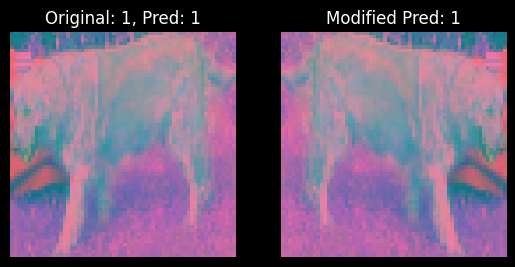

In [43]:
import matplotlib.pyplot as plt

# Take one test image
img_sample = X_test[0]
true_label = np.argmax(y_test[0])

# Predict original
pred_original = np.argmax(model.predict(img_sample[np.newaxis, ...]))
print(f"True label: {true_label}, Original prediction: {pred_original}")

# Flip an image to check if the model can predict correctly
img_mod = cv2.flip((img_sample*255).astype(np.uint8), 1)
img_mod = img_mod / 255.0

pred_modified = np.argmax(model.predict(img_mod[np.newaxis, ...]))
print(f"Prediction after modification: {pred_modified}")




plt.subplot(1,2,1)
plt.imshow(img_sample)
plt.title(f"Original: {true_label}, Pred: {pred_original}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_mod)
plt.title(f"Modified Pred: {pred_modified}")
plt.axis('off')

plt.show()

it does predict it, but cantt be sure on how it was predicted as the validation is only 0.62

34. What does interpretability mean in the context of machine learning?
    - Interpretability is the ability to understand how a model makes predictions.
    - It involves knowing which features the model relies on, so you can explain why a certain prediction was made.

35. Why is explainability important in applications such as medicine or finance?
    - In medicine, blindly trusting predictions can be risky if you don’t know why a model recommends a treatment.
    - In finance, a model that makes investment decisions without explanation can lead to unjustified losses, and you can’t explain or correct mistakes reliably.

36. Can a highly accurate model still be problematic if it is difficult to interpret? Why?
    - Yes. A model might rely on misleading or irrelevant features (e.g., image backgrounds) even if accuracy is high.
    - Lack of interpretability makes it hard to trust, debug, or safely deploy on new datasets, which can lead to unexpected failures.